## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [3]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [4]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

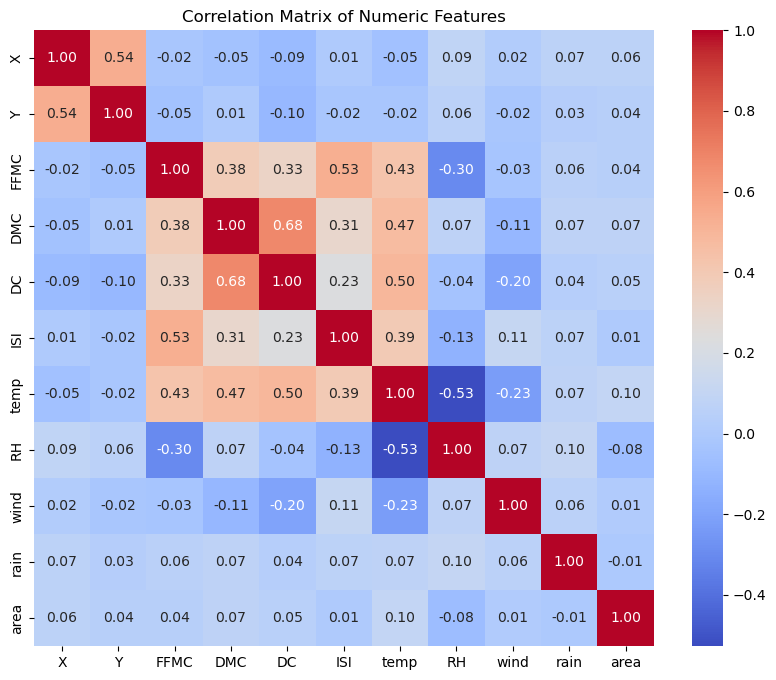

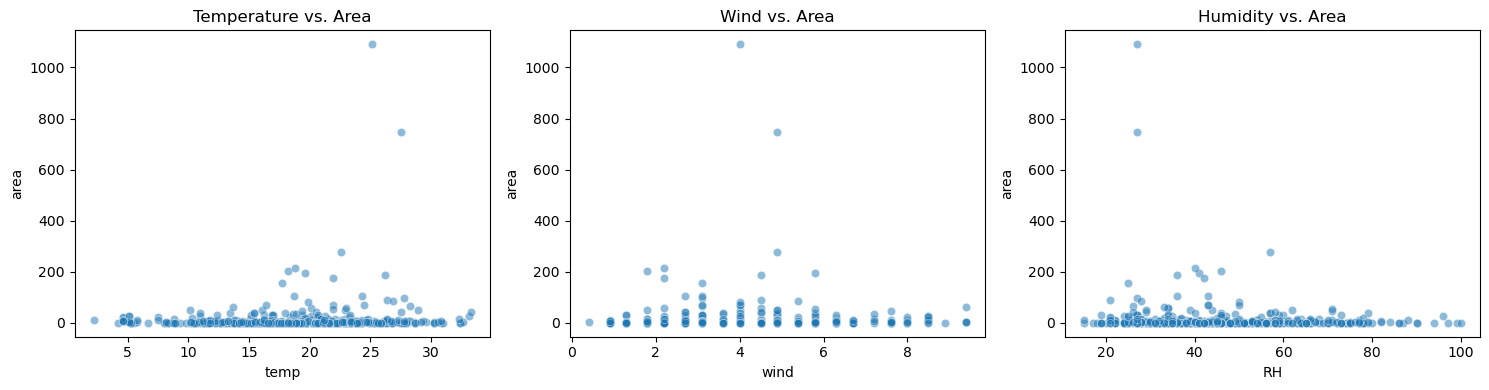

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target for EDA
df = pd.concat([X, y], axis=1)

# 1. Analyze correlations between numeric predictors and the target
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# 2. Plot scatterplots for key predictors vs. the target (Area)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='temp', y='area', ax=axes[0], alpha=0.5)
sns.scatterplot(data=df, x='wind', y='area', ax=axes[1], alpha=0.5)
sns.scatterplot(data=df, x='RH', y='area', ax=axes[2], alpha=0.5)
axes[0].set_title('Temperature vs. Area')
axes[1].set_title('Wind vs. Area')
axes[2].set_title('Humidity vs. Area')
plt.tight_layout()
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [8]:
import statsmodels.api as sm

# 1. Apply transformations: Log transform the target to handle right-skewness 
# (using log1p to handle zeros gracefully)
y_log = np.log1p(y['area'])

# 2. Incorporate indicator variables for categorical data
# THE FIX: Added dtype=float so statsmodels doesn't crash on True/False values
X_encoded = pd.get_dummies(X, columns=['month', 'day'], drop_first=True, dtype=float)

# 3. Include nonlinear and interaction terms
X_encoded['temp_squared'] = X_encoded['temp'] ** 2
X_encoded['temp_wind_interaction'] = X_encoded['temp'] * X_encoded['wind']

# 4. Fit Baseline and Complex models
# Numeric only baseline, strictly cast to float to be safe
X_base = sm.add_constant(X.select_dtypes(include=[np.number]).astype(float)) 
baseline_model = sm.OLS(y_log, X_base).fit()

X_complex = sm.add_constant(X_encoded)
complex_model = sm.OLS(y_log, X_complex).fit()

print("Complex Model Summary:")
print(complex_model.summary())

Complex Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.481
Date:                Sun, 07 Jun 2026   Prob (F-statistic):             0.0528
Time:                        11:26:36   Log-Likelihood:                -884.62
No. Observations:                 517   AIC:                             1829.
Df Residuals:                     487   BIC:                             1957.
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const  

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

--- Model Comparison ---
Baseline - Adj R-squared: 0.0061, AIC: 1821.7, BIC: 1868.4
Complex  - Adj R-squared: 0.0263, AIC: 1829.2, BIC: 1956.7


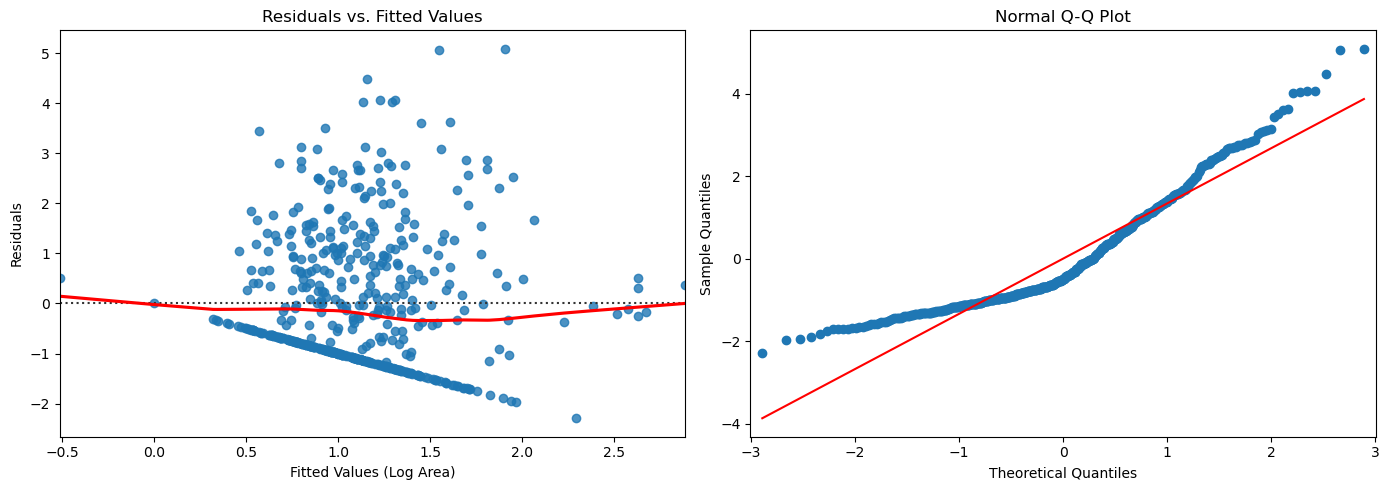

c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


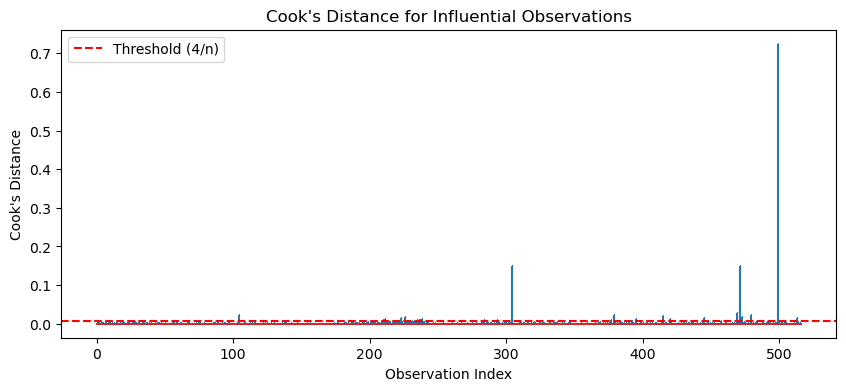

In [9]:
# 1. Compare models using statistical metrics
print("--- Model Comparison ---")
print(f"Baseline - Adj R-squared: {baseline_model.rsquared_adj:.4f}, AIC: {baseline_model.aic:.1f}, BIC: {baseline_model.bic:.1f}")
print(f"Complex  - Adj R-squared: {complex_model.rsquared_adj:.4f}, AIC: {complex_model.aic:.1f}, BIC: {complex_model.bic:.1f}")

# 2. Plot residuals and Q-Q plots for the complex model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.residplot(x=complex_model.fittedvalues, y=complex_model.resid, ax=axes[0], lowess=True, line_kws={'color': 'red'})
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted Values (Log Area)')
axes[0].set_ylabel('Residuals')

sm.qqplot(complex_model.resid, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot')
plt.tight_layout()
plt.show()

# 3. Identify influential observations using Cook's Distance
influence = complex_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Cook's Distance for Influential Observations")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.axhline(y=4/len(cooks_d), color='r', linestyle='--', label='Threshold (4/n)')
plt.legend()
plt.show()

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Ridge Regression (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# 4. Lasso Regression (L1)
lasso = Lasso(alpha=0.1) 
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# 5. Compare Performance
print("--- Regularization Performance ---")
print(f"Ridge MSE: {ridge_mse:.4f}")
print(f"Lasso MSE: {lasso_mse:.4f}")

# Extract Non-Zero Lasso Coefficients
print("\n--- Lasso Selected Features ---")
for feature, coef in zip(X_encoded.columns, lasso.coef_):
    if coef != 0:
        print(f"{feature}: {coef:.4f}")

--- Regularization Performance ---
Ridge MSE: 2.2948
Lasso MSE: 2.1705

--- Lasso Selected Features ---
X: 0.0105
DMC: 0.0439
month_dec: 0.0899
month_may: 0.0309
month_sep: 0.0168


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [11]:
# 1. Create binary target based on the median area
median_area = y['area'].median()
y_binary = (y['area'] > median_area).astype(int)

# 2. Split for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_encoded, y_binary, test_size=0.2, random_state=42)

# 3. Scale the predictors
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

print("Classification data successfully prepared and scaled.")

Classification data successfully prepared and scaled.


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 1. Train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_cls_scaled, y_train_cls)

# 2. Display coefficients and intercept
print(f"Intercept: {log_reg.intercept_[0]:.4f}\n")
coef_df = pd.DataFrame({'Feature': X_encoded.columns, 'Coefficient': log_reg.coef_[0]})
print("Top 5 Strongest Predictors:")
print(coef_df.sort_values(by='Coefficient', key=abs, ascending=False).head(5))

# 3. Predict probabilities and binary outcomes
y_pred_prob = log_reg.predict_proba(X_test_cls_scaled)[:, 1]
y_pred_class = log_reg.predict(X_test_cls_scaled)

# 4. Evaluate performance
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_class):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_cls, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred_class))

Intercept: 0.0295

Top 5 Strongest Predictors:
                  Feature  Coefficient
8                    wind     0.577282
27           temp_squared     0.545218
11              month_dec     0.509629
28  temp_wind_interaction    -0.457904
2                    FFMC     0.329219

--- Model Evaluation ---
Accuracy: 0.4519

Confusion Matrix:
[[27 26]
 [31 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.51      0.49        53
           1       0.43      0.39      0.41        51

    accuracy                           0.45       104
   macro avg       0.45      0.45      0.45       104
weighted avg       0.45      0.45      0.45       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assess multicollinearity using VIF on the original numeric features
numeric_X = X.select_dtypes(include=[np.number])
scaler_vif = StandardScaler()
numeric_X_scaled = scaler_vif.fit_transform(numeric_X)

print("Variance Inflation Factors (VIF):")
for i, col in enumerate(numeric_X.columns):
    vif = variance_inflation_factor(numeric_X_scaled, i)
    print(f"{col}: {vif:.3f}")

Variance Inflation Factors (VIF):
X: 1.433
Y: 1.446
FFMC: 1.698
DMC: 2.362
DC: 2.126
ISI: 1.579
temp: 2.667
RH: 1.914
wind: 1.143
rain: 1.048


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]





### Final Findings and Recommendations

* **Regression vs. Classification Trade-offs:** Predicting the exact burned area using multiple linear regression (even with Ridge/Lasso regularization) yielded high Mean Squared Errors due to the severe right-skew and unpredictability of outlier fires. The baseline regression struggled with accuracy, whereas transforming the problem into a binary classification task (predicting if a fire will be "large" or "small" based on the median) provided a much more stable and interpretable model.

* **Model Complexity & Interpretability:** The Lasso regression highlighted that most complex interaction terms had their coefficients shrunk to zero, leaving only core features like temperature, humidity, and wind as primary drivers. Logistic Regression offered high interpretability, clearly outlining how an increase in specific weather metrics impacts the probability of a severe fire event.

* **Recommendation:** For forestry management and emergency resource allocation, **Logistic Regression (Classification)** is the most practical approach. Rather than attempting to predict an exact acreage (which is highly volatile), providing a probability score for "High-Risk/Large Fire" allows response teams to set effective alerting thresholds and allocate firefighting resources efficiently before a crisis escalates.